<a name="Notebook-Start"></a>

---

<center>
<font color = lightblue, size = 30> Regression With Nonlinear Features </font>
</center>

---

In our last Lesson, we learned about building linear models for regression. In a linear model, predictions are a linear combination of the available features. So for example, if we have three features ($X_1, X_2, X_3$), the model predicts an output:

<br>

<center>
<font size = 5>
 $Y = m_1 \hspace{0.1 pc} X_1 + m_2 \hspace{0.1 pc} X_2 + m_3 \hspace{0.1 pc} X_3 + b$
</font>
</center>

<br>

More generally, we can express the output of the models as follows. If our model has ($N$) features then:

<br>

<center>
<font size = 5>
 $Y = \displaystyle \Sigma^N_{i=1} \hspace{0.1 pc} m_i \hspace{0.1 pc} X_i + b$
</font>
</center>

<br>

In this lesson we will learn to build higher order models with sklearn. We will create both a first degree (linear) regression model as well as a second degree (quadratic) regression model. Finally, we will compare the performance of the two models and determine which model best fits the data.

## Notebook Index:

* [Import Python Libraries](#Import-Python-Libraries)

* [Define Useful Functions](#Define-Useful-Functions)

* [Load The Dataset](#Load-the-Dataset)

* [Visualize The Data](#Visualize-the-Data)

* [Linear Model](#Linear-Model)

* [Quadratic Model](#Quadratic-Model)

<a name="Import-Python-Libraries"></a>

---

<font size = 6> Import Python Libraries </font>

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import plotly.express as px

[Return to Top](#Notebook-Start)

<a name="Define-Useful-Functions"></a>

---

<font size = 6> Define Useful Functions </font>

---

In [5]:
#@title This cell defines the plot_data, plot_model, and regression functions.

##=============================================================================================##
## Function:  plot_data                                                                        ##
##                                                                                             ##
## Input(s):  x_data      - Independent variable (x-axis) data; Must be Panda Series           ##
##            y_data      - Dependent variable (y-axis) data; Must be Panda Series             ##
##            title       - Graph title                                                        ##
##            axis_labels - Override the x-axis and y-axis labels                              ##
##            origin_on   - Set's the graph window to include the origin, if true              ##
##                                                                                             ##
## Output(s): graph       - Matplotlib axes object, can be used for overplotting               ##
##=============================================================================================##

def plot_data(x_data, y_data, title, axis_labels = [], origin_on = False):

  # Set the x-label and y-label:

  if (axis_labels == []):

    x_label = x_data.name
    y_label = y_data.name

  else:

    x_label = axis_labels[0]
    y_label = axis_labels[1]

  # Define the boundaries for the graph window:

  x_min = x_data.min()
  x_max = x_data.max()

  y_min = y_data.min()
  y_max = y_data.max()

  if (origin_on == True): a = 0.0

  else: a = 0.5

  b = 1.1

  if (x_min > 0): x_lower = a * x_min

  else: x_lower = b * x_min

  if (x_max > 0): x_upper = b * x_max

  else: x_upper = a * x_max

  if (y_min > 0): y_lower = a * y_min

  else: y_lower = b * y_min

  if (y_max > 0): y_upper = b * y_max

  else: y_upper = a * y_max

  # Create the Matplotlib figure:

  figure = plt.figure(figsize = (8, 6))

  # Add a graph to the figure:

  graph = figure.add_axes([0, 0, 1, 1])

  # Set the graph title and labels:

  graph.set_title(title)

  graph.set_xlabel(x_label)

  graph.set_ylabel(y_label)

  # Apply a grid to the graph:

  graph.grid()

  # Set the boundaries of the graph window:

  graph.set_xlim([x_lower, x_upper])
  graph.set_ylim([y_lower, y_upper])

  # Create a scatterplot of the data:

  sns.scatterplot(x = x_data, y = y_data, ax = graph)

  # Return the Graph Object

  return graph

##=============================================================================================##
## Function:  plot_model                                                                       ##
##                                                                                             ##
## Input(s):  X            - Dataframe containing the model feature data                       ##
##            y            - Series containing the model target data                           ##
##            coefficients - List of the model's coefficients                                  ##
##            intercept    - Model's intercept                                                 ##
##            title        - Graph title                                                       ##
##            model_label  - Legend label for the model                                        ##
##            axis_labels  - Override the x-axis and y-axis labels                             ##
##                                                                                             ##
## Output(s): None                                                                             ##
##=============================================================================================##

def plot_model(X, y, coefficients, intercept, title, model_label, axis_labels = [],
               origin_on = False):

  # Choose the x axis data

  x = X.iloc[:, 0]

  # Create the raw data plot

  graph = plot_data(x, y, title, [x_label, y_label], origin_on)

  # Create a list of independent variable values:

  model_x = np.arange(x.min(), x.max(), .1)

  # Calculate the dependent variables values based on the model's coefficients and intercept:

  order = len(X.columns)

  model_y = np.zeros(len(model_x))

  for i in range(0, order):

    model_y += np.pow(model_x, i + 1) * coefficients[i]

  model_y += intercept

  # Plot the linear models:

  sns.lineplot(x = model_x, y = model_y, color = 'red', ax = graph, label = model_label)

##=============================================================================================##
## Function:  regression                                                                       ##
##                                                                                             ##
## Input(s):  X            - Feature data (independent variables)                              ##
##            y            - Target data (dependent variable)                                  ##
##            verbose      - Print model information (if True); Default is False               ##
##                                                                                             ##
## Output(s): coefficients - List of the model's coefficients                                  ##
##            intercept    - Model's intercept                                                 ##
##            rmse         - Model's root mean squared error                                   ##
##=============================================================================================##

def regression(X, y, verbose = False):

  # Create a regression model

  model = LinearRegression()

  # Fit the regression model

  model.fit(X, y)

  # Get the regression model's predictions for the target data based on the feature data

  predictions = model.predict(X)

  # Compare the model's predictions with the target data and compute the mean squared error

  mse = mean_squared_error(predictions, y)

  # Compute the root mean squared error from the mean squared error

  rmse = np.sqrt(mse)

  # Get the coefficients from the model

  coefficients = model.coef_

  # Get the intercept from the model

  intercept = model.intercept_

  # If verbose is True, print model information

  if (verbose == True):

    print()

    print("Model Coefficients", np.round(coefficients, 3))

    print()

    print("Model Intercept", np.round(intercept, 3))

    print()

    print("Model RMSE:", np.round(rmse, 3))

  # Return the coefficients, intercept, and root mean squared error

  return coefficients, intercept, rmse

[Return to Top](#Notebook-Start)

<a name="Load-the-Dataset"></a>

---

<font size = 6> Load The Dataset </font>

---

For this exercise, we will use a dataset containing data on automobiles including their horsepower and fuel economy. Our goal is to build a model to predict a car's fuel efficiency, the `mpg` column, using the car's horsepower, the `horsepower` column, as our model's feature.

<br>

Note: horsepower is a unit used to measure the power supplied by a car's engine to its axels. One horsepower is equal to 745.7 watts.

In [7]:
##=============================================================================================##
## Load in the Full Data Set:                                                                  ##
##=============================================================================================##

raw_data = pd.read_csv('auto.csv')

print()
print("Raw Data:")

display(raw_data.head())

##=============================================================================================##
## Separate the Feature and Target Data and Drop Any Rows Missing Data:                        ##
##=============================================================================================##

cleaned_data = raw_data[['mpg', 'horsepower']].dropna()

print()
print("Cleaned Data:")

display(cleaned_data.head())


Raw Data:


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino



Cleaned Data:


,mpg,horsepower
0,18.0,130.0
1,15.0,165.0
2,18.0,150.0
3,16.0,150.0
4,17.0,140.0


[Return to Top](#Notebook-Start)

<a name="Visualize-the-Data"></a>

---

<font size = 6> Visualize The Data </font>

---

Next, we will create a scatterplot of `horsepower` vs. `mpg` to create a visualization of the relationship between the data feature and target. On the x-axis, we have the total engine power in horsepower and on the y-axis, we have the fuel efficiency in miles per gallon.

<Axes: title={'center': 'Horse Power Vs Gas Milage'}, xlabel='Horse Power', ylabel='Gas Milage'>

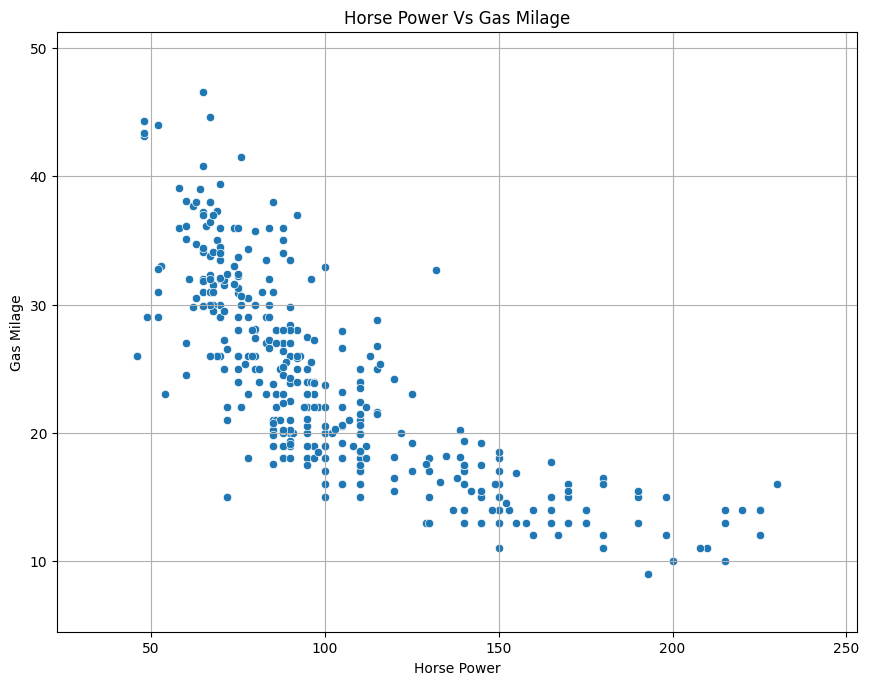

In [8]:
##=============================================================================================##
## Split the Data Into Dependent and Independent Variables:                                    ##
##=============================================================================================##

x_data = cleaned_data["horsepower"]

y_data = cleaned_data["mpg"]

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

plot_data(x_data, y_data, "Horse Power Vs Gas Milage", ["Horse Power", "Gas Milage"], False)

In the plot above, we see a strong inverse correlation. As the engine
power grows, the gas milage decreases. This makes intuitive sense because an engine which is more powerful will tend to be part of a larger
vehicle. And since larger vehicles have more mass to move around, we
expect them to be less fuel efficient. Furthermore, we can see from this graph that the relationship between horse power and gas milage is noticeably nonlinear.

[Return to Top](#Notebook-Start)

<a name="Linear-Model"></a>

---

<font size = 6> Linear Model </font>

---

Let's start with a linear model to relate the gas milage to horsepower and see how it does matching the data.


Model Coefficients [-0.158]

Model Intercept 39.936

Model RMSE: 4.893


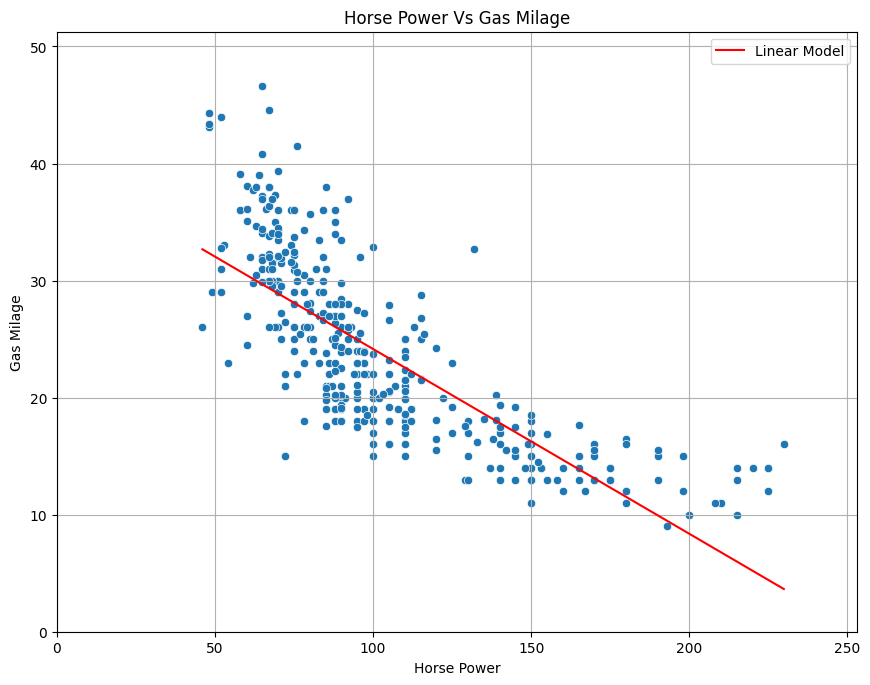

In [9]:
##=============================================================================================##
## Create the Model:                                                                           ##
##=============================================================================================##

# Identify the model's feature data:

X_linear = cleaned_data[["horsepower"]]

# Identify the model's target data:

y = cleaned_data["mpg"]

# Get the model's coefficients, intercept, and rmse:

linear_coef, linear_intercept, linear_rmse = regression(X_linear, y, True)

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the graph title:

title = "Horse Power Vs Gas Milage"

# Set the x-axis label:

x_label = "Horse Power"

# Set the y-axis label:

y_label = "Gas Milage"

# Set the model label:

m_label = "Linear Model"

plot_model(X_linear, y, linear_coef, linear_intercept, title, m_label, [x_label, y_label], True)

We can see from the above, that the linear model has a root mean squared error of 4.893. We can also see that this model fails to capture the shape of the relationship between the fuel efficiency and the engine power. The shape of the relationship, it feels sort of arcing or curved. But because we're using simple linear regression here, we can't possibly get that curvy shape. With what we know so far, it seems impossible to capture this nonlinear relationship between the miles per gallon and our horsepower.

[Return to Top](#Notebook-Start)

<a name="Quadratic-Model"></a>

---

<font size = 6> Quadratic Model </font>

---

Naturally, a simple linear regression model could never produce a curved line because simple linear regression models do not have higher order terms.

<br>

Suppose we wanted to generalize our idea of a model with squared features. One possible approach would be to create a new type of model; a squared regression model. In such a model, predictions would be the weighted sum of the features, plus the weighted sum of the features squared, plus an intercept term.

<br>

<center>
<font size = 5>
 $Y = \displaystyle \Sigma^N_{i=1} \hspace{0.1 pc} n_i \hspace{0.1 pc} X^2_i + m_i \hspace{0.1 pc} X_i + b$
</font>
</center>

<br>

It turns out there's a much simpler solution where we can still use the same structure that we developed for linear regression models and the same scikitlearn library but get nonlinear behavior.

<br>

Now, this is going to seem like a trick, but this is really what's done in the
real-world and it works very well. All we do is add a squared feature to our
model. We will first compute the square of the data in the `horsepower` column. Then we will assign these squared values to a new column with name `hp2`. Now, we can use a multilinear approach to modelling the data, where the squared data becomes a new 'linear dimension'.

<br>

To build our quadratic model, we will first need to create values which are the square of the data in the `horsepower` column.  We will assign these squared values to a new column with name `hp2`.

In [10]:
##=============================================================================================##
## Add the Squared Horsepower Data:                                                            ##
##=============================================================================================##

cleaned_data["hp2"] = cleaned_data['horsepower']**2

display(cleaned_data.head())

,mpg,horsepower,hp2
0,18.0,130.0,16900.0
1,15.0,165.0,27225.0
2,18.0,150.0,22500.0
3,16.0,150.0,22500.0
4,17.0,140.0,19600.0


Now, we can use a multilinear approach to modelling the data, where the squared data becomes a new 'linear dimension'.


Model Coefficients [-0.466  0.001]

Model Intercept 56.9

Model RMSE: 4.357


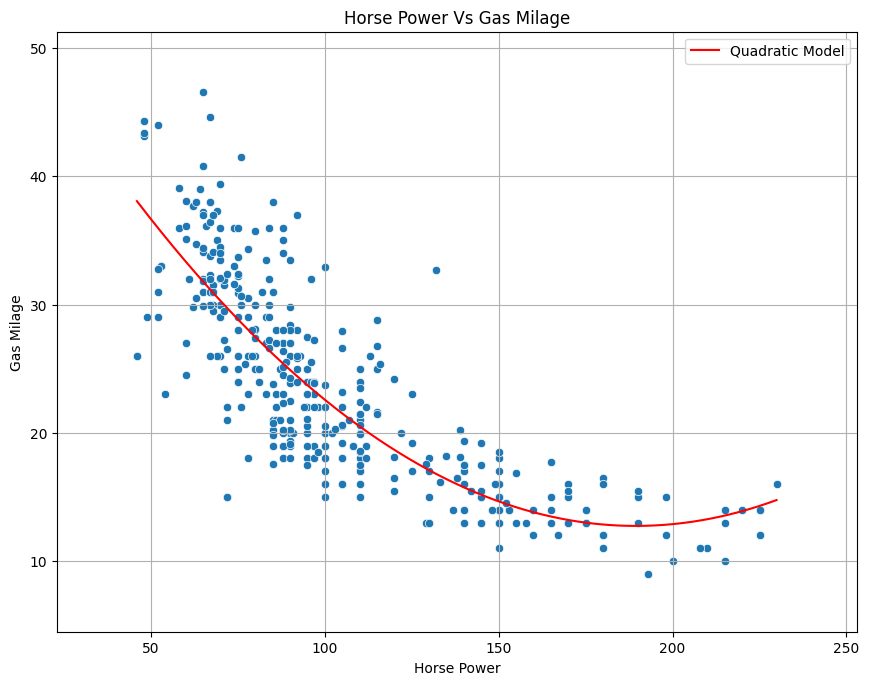

In [12]:
##=============================================================================================##
## Create the Model:                                                                           ##
##=============================================================================================##

# Identify the model's feature data:

X_quad = cleaned_data[["horsepower", "hp2"]]

# Identify the model's target data:

y = cleaned_data["mpg"]

# Get the model's coefficients, intercept, and rmse:

quad_coef, quad_intercept, quad_rmse = regression(X_quad, y, True)

##=============================================================================================##
## Create a Plot of the Data:                                                                  ##
##=============================================================================================##

# Set the graph title:

title = "Horse Power Vs Gas Milage"

# Set the x-axis label:

x_label = "Horse Power"

# Set the y-axis label:

y_label = "Gas Milage"

# Set the model label:

m_label = "Quadratic Model"

plot_model(X_quad, y, quad_coef, quad_intercept, title, m_label, [x_label, y_label], False)

We can see from the above, that the quadratic model has a root mean squared error of 4.357, a noticable improvement over the linear model. We can also see that this model better captures the shape of the relationship between the fuel efficiency and the engine power.

[Return to Top](#Notebook-Start)